In [8]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
from scipy.integrate import cumulative_trapezoid
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

import deepxde as dde
import matplotlib.pyplot as plt
 
import time

In [9]:
def make_lam_fn(B):
    
    def lambda_func(y):
        y = np.clip(np.asarray(y), -1.0, 1.0)
        return 50.0 * np.cos(B * np.arccos(y)) 
    
    return lambda_func


def solve_k(lambda_func, spatial):
    """
    求解 k(x,y) on 0<=y<=x<=1:
        k_xx - k_yy = lambda(y) * k,
        k(x,0)=0,  k(x,x) = -1/2 * ∫_0^x lambda(y) dy.

    参数
    ----
    lambda_func : callable,  λ(y)，支持向量输入
    N           : int，均匀网格点数（当 spatial=None 时生效）
    spatial     : ndarray，可选，若提供则使用该均匀网格（长度 N）作为 x、y
    

    返回
    ----
    Krs:(Nr,Ns) 是 (r,s) 域的解
    """   
    N = len(spatial) 
    # ---------- (r,s) 网格（行=r，列=s） ----------
    Ns = N                 # s ∈ [0,1]
    Nr = 2*N - 1           # r ∈ [0,2]
    s = np.linspace(0.0, 1.0, Ns)
    r = np.linspace(0.0, 2.0, Nr)
    h = s[1] - s[0]        # 亦即 dr = ds = 1/(N-1)

    # Rg, Sg = np.meshgrid(r, s, indexing="ij")    # 形状 (Nr, Ns)
    # tol = 10*np.finfo(float).eps
    # valid = (Sg <= Rg + tol) & (Rg <= 2.0 - Sg+ tol)        # 合法物理域
    i = np.arange(Nr)[:, None]      # 形状 (Nr, 1)  → 行索引 r
    j = np.arange(Ns)[None, :]      # 形状 (1, Ns)  → 列索引 s
    valid = (i >= j) & (i <= (Nr - 1 - j))


    Krs = np.full((Nr, Ns), np.nan)              # 解阵（行=r，列=s）

    # ---------- 边界条件 ----------
    # s=0：k(r,0) = -1/2 ∫_0^{r/2} λ(y) dy
    y_int = np.linspace(0.0, 1.0, N)
    lam_y = lambda_func(y_int)
    F = -0.5 * cumulative_trapezoid(lam_y, y_int, initial=0.0)  # F(x)= -1/2∫_0^x λ
    Krs[:, 0] = np.interp(r/2.0, y_int, F)

    # r=s（y=0）：k=0（j=0 处 F(0)=0 已一致，从 j=1 起设置）
    for j in range(1, Ns):
        i = np.argmin(np.abs(r - s[j]))
        Krs[i, j] = 0.0

    # ---------- Goursat 推进（预测-校正，源项中心近似） ----------
    for i in range(Nr-1):      # r 轴
        for j in range(Ns-1):  # s 轴
            if not (valid[i, j] and valid[i+1, j] and valid[i, j+1] and valid[i+1, j+1]):
                continue
            if np.isnan(Krs[i+1, j]) or np.isnan(Krs[i, j+1]) or np.isnan(Krs[i, j]):
                continue

            rc = 0.5*(r[i] + r[i+1])
            sc = 0.5*(s[j] + s[j+1])
            yc = (rc - sc)/2.0
            a = 0.25 * float(lambda_func(yc))    # a = (1/4) λ((r-s)/2)

            k_tilde = Krs[i+1, j] + Krs[i, j+1] - Krs[i, j]
            center_approx = (Krs[i+1, j] + Krs[i, j+1] + Krs[i, j] + k_tilde) / 4.0
            Krs[i+1, j+1] = k_tilde + (h*h) * a * center_approx
    
    r_index = np.arange(N-1,2*N - 1)
    s_index = np.arange(N-1,-1,-1) # 最下边的那条边,从右侧往左
    Kxy_gain = Krs[r_index,s_index]
    
    return Krs, Kxy_gain

def solveIntegralFD(x, lam):
     
    dx = x[1] - x[0]    
    k = np.zeros((len(x), len(x)))
    # First we calculate a at each timestep
    a = lam
    
    # FD LOOP
    k[1][1] = -(a[1] + a[0]) * dx / 4
    for i in range(1, len(x)-1):
        k[i+1, 0] = 0
        k[i+1,i+1] = k[i,i]-dx/4.0*(a[i-1] + a[i])
        k[i+1,i] = k[i,i] - dx/2 * a[i]
        for j in range(1, i):
                k[i+1,j] = -k[i-1,j] + k[i,j+1] + k[i,j-1] + a[j]*(dx**2)*(k[i,j+1]+k[i,j-1])/2
    return k

def get_simpson_coeff(spatial):
     
    nx = len(spatial)
    dx = spatial[1] - spatial[0]
    
    simpson_coeff = np.ones(nx)
    simpson_coeff[1:-1:2] = 4   
    simpson_coeff[2:-1:2] = 2      
    simpson_coeff *=  (dx / 3.0)
    
    return simpson_coeff

    
def build_CN_operators(spatial, dt, lam, control_type, K_vals):
     
    dx = spatial[1] - spatial[0]
    Nx = len(spatial)  
    alpha = dt / (2.0 * dx**2)
    beta = lam * dt / 2.0

    A_main = np.concatenate([[1.0], np.ones(Nx-2) + 2 * alpha * np.ones(Nx-2) - beta[1:-1], [1.0]])
    A_upper = np.concatenate([[0.0], -alpha * np.ones(Nx-2)])
    A_lower = np.concatenate([-alpha * np.ones(Nx-2), [0.0]])
    A = diags([A_lower, A_main, A_upper], offsets=[-1, 0, 1], shape=(Nx, Nx)).tolil()

    B_main = np.concatenate([[0.0], np.ones(Nx-2) - 2 * alpha * np.ones(Nx-2) + beta[1:-1], [0.0]])
    B_upper = np.concatenate([[0.0], alpha * np.ones(Nx-2)])
    B_lower = np.concatenate([alpha * np.ones(Nx-2), [0.0]])
    B = diags([B_lower, B_main, B_upper], offsets=[-1, 0, 1], shape=(Nx, Nx)).tolil()


    if control_type == 'closed':
        simpson_coeff = get_simpson_coeff(spatial)
        row_update = -(simpson_coeff * K_vals)
        A[-1, :] = A[-1, :].toarray() + row_update
        # B[-1,:] = -row_update

    A = A.tocsr()
    B = B.tocsr()
    return A, B 


def step_CN(u_last, A, B):
     
    u_last =  u_last.reshape(-1)
    rhs = B @ u_last
    u_new = spsolve(A, rhs)
               
    return  u_new 




def plot_u_surface(x, t, u, title="u(x,t) Surface"):
    # U shape: (Nt, Nx), x: (Nx,), t: (Nt,)
    T, X = np.meshgrid(t, x, indexing='ij')  # T, X 都是 (Nt, Nx)
    fig = plt.figure(figsize=(7,5))
    ax = fig.add_subplot(111, projection='3d')

    # 可选：大网格时做下采样以提速
    max_points = 200_000
    skip_t = max(1, int(np.ceil(T.size / max_points)))
    T_s = T[::skip_t, ::skip_t]
    X_s = X[::skip_t, ::skip_t]
    U_s = u[::skip_t, ::skip_t]

    surf = ax.plot_surface(X_s, T_s, U_s, linewidth=0, antialiased=True)
    ax.set_xlabel('x')
    ax.set_ylabel('t')
    ax.set_zlabel('u')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()     

In [5]:
def simulate_pde_trajectory(lam_param, spatial, nt, dt):
    Nx = len(spatial)
    lambda_func = make_lam_fn(lam_param)
    lam_profile = lambda_func(spatial)
    
    # Solve kernel k(x,y)
    _, Kxy_gain = solve_k(lambda_func, spatial)

    # Init PDE
    u = np.zeros((nt, Nx))
    u[0,:] = 10.0

    # Build CN
    A, B = build_CN_operators(spatial, dt, lam_profile, Kxy_gain)

    # Time marching
    for k in range(1, nt):
        u[k,:] = step_CN(u[k-1,:], A, B)

    # boundary derivative u_x(0,t)  (左端)
    dx = spatial[1] - spatial[0]
    u_x0 = (u[:,1] - u[:,0]) / dx

    # boundary control U(t) = u(1,t)  (右端)
    U_ctrl = u[:,-1]

    return lam_profile.astype(np.float32), u_x0.astype(np.float32), U_ctrl.astype(np.float32)


In [10]:
def simulate_one_trajectory(lam_param, spatial, nt, dt):

    Nx = len(spatial)
    dx = spatial[1] - spatial[0]    
    lambda_func = make_lam_fn(lam_param)
    lam_profile = lambda_func(spatial)                  

    _, Kxy_gain = solve_k(lambda_func, spatial)

    u = np.zeros((nt, Nx), dtype=np.float32)
    u[0,:] = 10.0
  
    A, B = build_CN_operators(spatial, dt, lam_profile, 'closed', Kxy_gain)

    for k in range(1, nt):
      u[k,:] = step_CN(u[k-1,:], A, B)

    # u_x0 = (u[:,1] - u[:,0]) / dx      # [nt]
    u_x0 = (-3*u[:, 0] + 4*u[:, 1] - u[:, 2]) / (2*dx)
    U_ctrl = u[:,-1]                   # [nt]

    return lam_profile.astype(np.float32), u_x0.astype(np.float32), U_ctrl.astype(np.float32)


In [20]:
class PDEControlDataset(Dataset):
    def __init__(self, lam_profiles, u_x0_seqs, U_seqs):
        # lam_profiles: [N_traj, Nx]
        # u_x0_seqs:   [N_traj, nt]
        # U_seqs:      [N_traj, nt]
        self.lam_profiles = torch.from_numpy(lam_profiles)  # float32
        self.u_x0_seqs    = torch.from_numpy(u_x0_seqs)
        self.U_seqs       = torch.from_numpy(U_seqs)

    def __len__(self):
        return self.lam_profiles.shape[0]

    def __getitem__(self, idx):
        return (self.lam_profiles[idx],   # [Nx]
                self.u_x0_seqs[idx],      # [nt]
                self.U_seqs[idx])         # [nt]


def build_dataset(num_traj, spatial, nt, dt):
    lam_profiles = []
    u_x0_list = []
    U_list = []

    # 按你的随机策略采样 lam 参数
    lam_params = np.random.uniform(4.0, 9.0, size=(num_traj,))

    # for lam_p in lam_params:
    #     lam_profile, u_x0, U_ctrl = simulate_one_trajectory(lam_p, spatial, nt, dt)
    #     lam_profiles.append(lam_profile)
    #     u_x0_list.append(u_x0)
    #     U_list.append(U_ctrl)

    for i, lam_p in enumerate(lam_params):
    # --- 原有逻辑 ---
        lam_profile, u_x0, U_ctrl = simulate_one_trajectory(lam_p, spatial, nt, dt)
        lam_profiles.append(lam_profile)
        u_x0_list.append(u_x0)
        U_list.append(U_ctrl)

        if (i + 1) % 100 == 0:
            percent = (i + 1) / num_traj * 100
            print(f"已采样: {i + 1}/{num_traj} ({percent:.1f}%)")
    

    lam_profiles = np.stack(lam_profiles, axis=0)  # [N_traj, Nx]
    u_x0_list    = np.stack(u_x0_list, axis=0)     # [N_traj, nt]
    U_list       = np.stack(U_list, axis=0)        # [N_traj, nt]

    return lam_profiles, u_x0_list, U_list

In [12]:
class LambdaEncoder(nn.Module):
    def __init__(self, spatial, emb_dim,
                 branch_hidden=(256, 256),
                 trunk_hidden=(128, 256),
                 activation="relu",
                 kernel="Glorot normal"):
        """
        spatial: numpy 一维数组, len(spatial) = nx
        emb_dim: lambda embedding 维度
        """
        super().__init__()

        self.nx = len(spatial)
        self.dim_x = 1

        # 1) DeepONet 结构
        branch = [self.nx, *branch_hidden]
        trunk  = [self.dim_x, *trunk_hidden]
        self.net1 = dde.nn.DeepONetCartesianProd(
            branch, trunk, activation, kernel
        )  

        # 2) 全连接，把 y(x) 的离散取值压成 embedding
        self.net2 = nn.Sequential(
            nn.Linear(self.nx, 64),
            nn.ReLU(),
            nn.Linear(64, emb_dim),
            nn.ReLU(),
        )

        # 3) 把 grid 存成 buffer（自动跟随模型 device）
        grid = torch.as_tensor(spatial, dtype=torch.float32).view(-1, 1)  # [nx, 1]
        self.register_buffer("grid", grid, persistent=False)

    def forward(self, lam_profile):
        """
        lam_profile: [batch, nx] (float32)
        return: lam_emb: [batch, emb_dim]
        """
        B = lam_profile.shape[0]

        # 保证 grid 跟 lam_profile 在同一个 device
        grid = self.grid.to(lam_profile.device)   # [nx, 1]

        # DeepONetCartesianProd 接收 (branch_input, trunk_input)
        # branch_input : [B, nx]
        # trunk_input  : [nx, 1]
        y = self.net1((lam_profile, grid))        # 通常输出 [B*nx, 1] 或 [B*nx]

        # reshape 成 [B, nx]
        y = y.view(B, self.nx)

        # 全连接做 embedding
        lam_emb = self.net2(y)                    # [B, emb_dim]
        return lam_emb
    

class LSTMControllerStep(nn.Module):
    def __init__(self, emb_dim, lstm_hidden=64, num_layers=1):
        """
        emb_dim: LambdaEncoder 的输出维度
        """
        super().__init__()

        # 输入 = 当前 u_x0_t 标量 + lambda embedding
        self.input_dim = 1 + emb_dim

        self.lstm = nn.LSTM(
            input_size=self.input_dim,
            hidden_size=lstm_hidden,
            num_layers=num_layers,
            batch_first=True,
        )

        self.mlp = nn.Sequential(
            nn.Linear(lstm_hidden, lstm_hidden),
            nn.ReLU(),                 # 可以换成 Tanh / GELU / ELU 等
            nn.Linear(lstm_hidden, 1),
        )

    def forward(self, u_x0_t, lam_emb, hidden=None):
        """
        u_x0_t: [B, 1] 当前时刻的边界导数
        lam_emb: [B, emb_dim] 同一条轨迹的 lambda 编码（对时间不变）
        hidden: (h, c)，各自 [num_layers, B, lstm_hidden]

        return:
          U_t: [B, 1]
          hidden: 更新后的 (h, c)
        """
        # 拼接条件：[B, 1 + emb_dim]
        x = torch.cat([u_x0_t, lam_emb], dim=-1)

        # LSTM 期望 [B, T, input_dim]，这里只有单步 T=1
        x = x.unsqueeze(1)             # [B, 1, input_dim]
        out, hidden = self.lstm(x, hidden)  # out: [B, 1, hidden]

        out = out.squeeze(1)           # [B, hidden]
        U_t = self.mlp(out)             # [B, 1]

        return U_t, hidden
    
class LambdaLSTMController(nn.Module):
    def __init__(self, spatial,
                 emb_dim=32,
                 lstm_hidden=64,
                 num_layers=1,
                 branch_hidden=(256, 256),
                 trunk_hidden=(128, 256),
                 activation="relu",
                 kernel="Glorot normal"):
        super().__init__()

        # 1) LambdaEncoder: lambda(x) -> lambda embedding
        self.lambda_encoder = LambdaEncoder(
            spatial=spatial,
            emb_dim=emb_dim,
            branch_hidden=branch_hidden,
            trunk_hidden=trunk_hidden,
            activation=activation,
            kernel=kernel,
        )

        # 2) LSTM 单步控制器
        self.step_net = LSTMControllerStep(
            emb_dim=emb_dim,
            lstm_hidden=lstm_hidden,
            num_layers=num_layers,
        )

    def forward(self, lam_profile, u_x0_seq, hidden=None):
        """
        lam_profile: [B, nx]
        u_x0_seq:   [B, T]   整条时间序列的边界导数
        hidden:     (h, c) or None

        return:
          U_seq: [B, T]
        """
        B, T = u_x0_seq.shape

        # lambda embedding 对时间不变
        lam_emb = self.lambda_encoder(lam_profile)   # [B, emb_dim]

        if hidden is None:
            device = lam_profile.device
            # num_layers, batch, hidden
            h0 = torch.zeros(self.step_net.lstm.num_layers, B,
                             self.step_net.lstm.hidden_size, device=device)
            c0 = torch.zeros_like(h0)
            hidden = (h0, c0)

        U_list = []

        # 按时间步循环
        for t in range(T):
            u_t = u_x0_seq[:, t:t+1]            # [B, 1]
            U_t, hidden = self.step_net(u_t, lam_emb, hidden)  # [B, 1]
            U_list.append(U_t)

        # 拼成 [B, T, 1] -> [B, T]
        U_seq = torch.cat(U_list, dim=1)
        return U_seq


In [14]:
###用这个
def train_controller(spatial,
    train_loader,
    val_loader,
    num_epochs=1000,
    emb_dim=32,
    hidden_size=64,
    num_layers=1,
    lr=1e-3,
    # save_prefix="lambda_lstm_controller",
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # === 1) 构造新的 DeepONet+LSTM 控制器 ===
    model = LambdaLSTMController(
        spatial=spatial,          
        emb_dim=emb_dim,
        lstm_hidden=hidden_size,
        num_layers=num_layers,
    ).to(device)

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,
    mode='min',
    factor=0.5,
    patience=20,
    threshold=1e-3,      
    threshold_mode='rel')
    
    train_hist = []
    val_hist = []

    best_val_loss = float("inf")
    best_state_dict = None

    for epoch in range(num_epochs):
        # ---------- 训练 ----------
        model.train()
        train_loss = 0.0

        for lam_batch,  u_x0_batch, U_batch in train_loader:
            # lam_batch: [B, nx]
            # u_x0_batch: [B, T]
            # U_batch: [B, T]
            lam_batch = lam_batch.to(device).float()
            u_x0_batch = u_x0_batch.to(device).float()
            U_batch = U_batch.to(device).float()

            optimizer.zero_grad()
            U_pred = model(lam_batch, u_x0_batch)   # [B, T]
            loss = criterion(U_pred, U_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * lam_batch.size(0)

        train_loss /= len(train_loader.dataset)

        # ---------- 验证 ----------
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for lam_batch,  u_x0_batch, U_batch in val_loader:
                lam_batch = lam_batch.to(device).float()
                u_x0_batch = u_x0_batch.to(device).float()
                U_batch = U_batch.to(device).float()

                U_pred = model(lam_batch, u_x0_batch)
                loss = criterion(U_pred, U_batch)
                val_loss += loss.item() * lam_batch.size(0)

        val_loss /= len(val_loader.dataset)
        scheduler.step(val_loss)

        train_hist.append(train_loss)
        val_hist.append(val_loss)

        current_lr = optimizer.param_groups[0]["lr"]
        print(
            f"Epoch {epoch+1}/{num_epochs} "
            f"- train_loss={train_loss:.4e}, val_loss={val_loss:.4e}, lr={current_lr:.3e}"
        )

        # ---------- 记录最优模型（内存里） ----------
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        # （可选）简单的 early stopping，防止无意义训练太久
        if current_lr < 1e-6:
            print("学习率过小，提前停止训练。")
            break

    print(f"训练结束，最佳验证 loss = {best_val_loss:.4e}")

    # 如果有记录最优参数，就载入
    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)
    

    return model, train_hist, val_hist

In [15]:

X = 1.0
dx = 0.01
spatial = np.linspace(0.0, X, int(round(X/dx))+1, dtype=np.float32)
nx = len(spatial)
nt = 2000
dt = 0.001

In [23]:
num_traj = 8000  
lam_profiles, u_x0_seqs, U_seqs = build_dataset(num_traj, spatial, nt, dt)
dataset = PDEControlDataset(lam_profiles, u_x0_seqs, U_seqs)
timestamp = time.strftime("%Y%m%d_%H%M%S")
save_dir="."
save_path = f"{save_dir.rstrip('/')}/outputfeedback_dataset_{timestamp}.npz"
np.savez(
        save_path,
        spatial=spatial,
        dt=np.array(dt, dtype=np.float32),
        lam_profiles=lam_profiles,
        u_x0_seqs=u_x0_seqs,
        U_seqs=U_seqs,
        lam_params=lam_profiles,
    )

已采样: 100/8000 (1.2%)
已采样: 200/8000 (2.5%)
已采样: 300/8000 (3.8%)
已采样: 400/8000 (5.0%)
已采样: 500/8000 (6.2%)
已采样: 600/8000 (7.5%)
已采样: 700/8000 (8.8%)
已采样: 800/8000 (10.0%)
已采样: 900/8000 (11.2%)
已采样: 1000/8000 (12.5%)
已采样: 1100/8000 (13.8%)
已采样: 1200/8000 (15.0%)
已采样: 1300/8000 (16.2%)
已采样: 1400/8000 (17.5%)
已采样: 1500/8000 (18.8%)
已采样: 1600/8000 (20.0%)
已采样: 1700/8000 (21.2%)
已采样: 1800/8000 (22.5%)
已采样: 1900/8000 (23.8%)
已采样: 2000/8000 (25.0%)
已采样: 2100/8000 (26.2%)
已采样: 2200/8000 (27.5%)
已采样: 2300/8000 (28.7%)
已采样: 2400/8000 (30.0%)
已采样: 2500/8000 (31.2%)
已采样: 2600/8000 (32.5%)
已采样: 2700/8000 (33.8%)
已采样: 2800/8000 (35.0%)
已采样: 2900/8000 (36.2%)
已采样: 3000/8000 (37.5%)
已采样: 3100/8000 (38.8%)
已采样: 3200/8000 (40.0%)
已采样: 3300/8000 (41.2%)
已采样: 3400/8000 (42.5%)
已采样: 3500/8000 (43.8%)
已采样: 3600/8000 (45.0%)
已采样: 3700/8000 (46.2%)
已采样: 3800/8000 (47.5%)
已采样: 3900/8000 (48.8%)
已采样: 4000/8000 (50.0%)
已采样: 4100/8000 (51.2%)
已采样: 4200/8000 (52.5%)
已采样: 4300/8000 (53.8%)
已采样: 4400/8000 (55.0%)
已采样:

In [24]:
save_dir="."
save_path = f"{save_dir.rstrip('/')}/outputfeedback_dataset_20251205_015956.npz"
data = np.load(save_path)
spatial      = data["spatial"]          # [Nx]
dt           = float(data["dt"])
lam_profiles = data["lam_profiles"]     # [N_traj, Nx]
u_x0_seqs    = data["u_x0_seqs"]        # [N_traj, nt]
# u_x1_seqs    = data["u_x1_seqs"]        # [N_traj, nt]
U_seqs       = data["U_seqs"]           # [N_traj, nt]

nx = lam_profiles.shape[1]

# 2) Dataset / DataLoader
dataset = PDEControlDataset(lam_profiles, u_x0_seqs, U_seqs)
n_total = len(dataset)
n_train = int(0.8 * n_total)
n_val   = n_total - n_train
torch.set_default_device("cpu")
train_set, val_set = torch.utils.data.random_split(dataset, [n_train, n_val])

batch_size=256
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_set, batch_size=batch_size, shuffle=False)

In [25]:
model, train_hist, val_hist = train_controller(
    spatial,
    train_loader,
    val_loader,
    num_epochs=1000,
    emb_dim=32,
    hidden_size=64,
    num_layers=1,
    lr=2e-3,
)


Epoch 1/1000 - train_loss=1.3703e+03, val_loss=1.2969e+03, lr=2.000e-03
Epoch 2/1000 - train_loss=1.2017e+03, val_loss=1.0194e+03, lr=2.000e-03
Epoch 3/1000 - train_loss=8.6811e+02, val_loss=6.7818e+02, lr=2.000e-03
Epoch 4/1000 - train_loss=5.6208e+02, val_loss=4.3039e+02, lr=2.000e-03
Epoch 5/1000 - train_loss=3.6670e+02, val_loss=2.9887e+02, lr=2.000e-03
Epoch 6/1000 - train_loss=2.8510e+02, val_loss=2.5462e+02, lr=2.000e-03
Epoch 7/1000 - train_loss=2.2912e+02, val_loss=1.7872e+02, lr=2.000e-03
Epoch 8/1000 - train_loss=1.5755e+02, val_loss=1.2287e+02, lr=2.000e-03
Epoch 9/1000 - train_loss=1.0479e+02, val_loss=7.8953e+01, lr=2.000e-03
Epoch 10/1000 - train_loss=6.7517e+01, val_loss=4.9002e+01, lr=2.000e-03
Epoch 11/1000 - train_loss=4.0599e+01, val_loss=3.3310e+01, lr=2.000e-03
Epoch 12/1000 - train_loss=2.8450e+01, val_loss=2.4216e+01, lr=2.000e-03
Epoch 13/1000 - train_loss=2.1582e+01, val_loss=1.8570e+01, lr=2.000e-03
Epoch 14/1000 - train_loss=1.6289e+01, val_loss=1.5193e+01, 

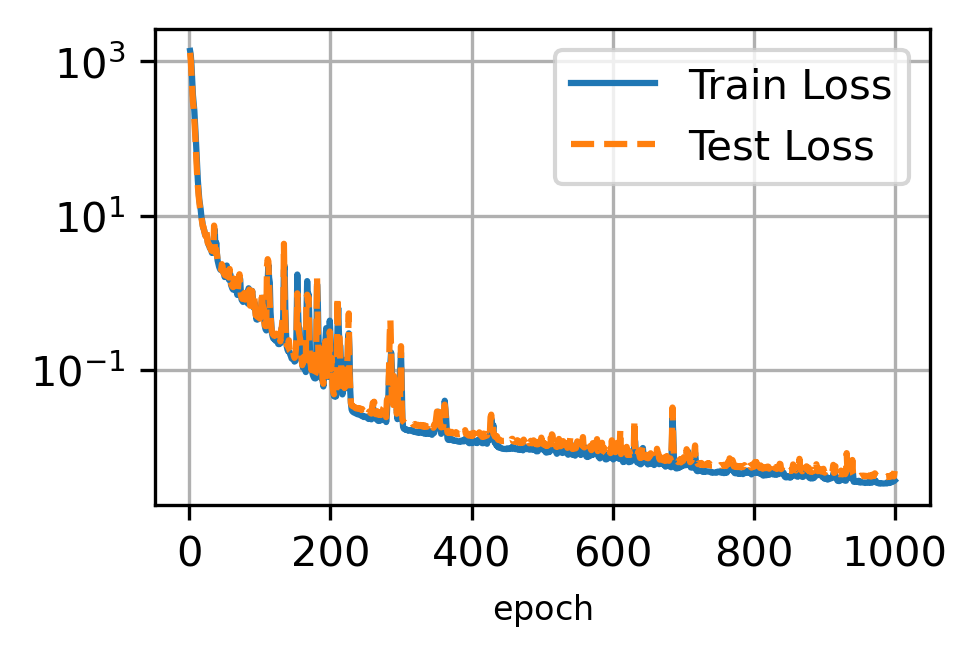

In [31]:
epochs = range(1, len(train_hist) + 1)

plt.figure(figsize=(1000 / 300, 618 / 300), dpi=300)
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
plt.plot(epochs, train_hist, label="Train Loss",linewidth=1.5)
plt.plot(epochs, val_hist,'--', label="Test Loss",linewidth=1.5)
plt.xlabel(r"$\mathrm{epoch}$",fontsize = 8 )
# plt.ylabel(r"$\mathrm{loss}$",fontsize = 8 )
plt.yscale("log") 
plt.legend(fontsize="10")   
plt.legend()
plt.grid(True)

plt.savefig("figs/loss_curve.jpg", dpi=300, bbox_inches="tight")
plt.show()